In [1]:
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
       
import torch
import numpy as np
import warp as wp

# Initialize Warp
wp.config.verify_autograd_array_access = False
wp.config.verbose = False
wp.init()

from sphWarpCore import radiusSearchCompactHashMap, sphOperation_warp
from sphWarpCore.enumTypes import *

from diffSPH.neighborhood import buildNeighborhood
from diffSPH.operations import SPHOperation
from diffSPH.enums import Operation, SupportScheme, GradientMode, LaplacianMode
from diffSPH.operations import KernelCorrectionScheme
from diffSPH.kernels import *
from diffSPH.plotting import visualizeParticles
from diffSPH.kernels import getSPHKernelv2

import matplotlib.pyplot as plt
from demo_util import *

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:
device = torch.device('cpu')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
targetNumNeighbors = 50
nx = 128
dim = 2
numParticles = nx**dim

warpOnly = False
periodic = True

kernel = KernelFunctions.Wendland2
supportMode = SupportScheme.Gather

markerSize = 8 if warpOnly else 2
gridVisualization = False 
gridResolution = 128
dx = 2.0 / nx

In [3]:
particleState, domain, adjacency, neighborhood, simulationState, measurements = prepData(nx, targetNumNeighbors, dim, device, periodic, warpOnly)
apparentVolume, crkDensity, crkState = computeCRKFactors(particleState, domain, kernel, adjacency = adjacency)

Module sphWarpCore.radiusSearch.wp_compactHash d133365 load on device 'cuda:0' took 2.72 ms  (cached)
Module sphWarpCore.operations.wp_density 4d00ae0 load on device 'cuda:0' took 1269.22 ms  (compiled)
Module sphWarpCore.crk.crk_volume bbb56f1 load on device 'cuda:0' took 771.46 ms  (compiled)
Module sphWarpCore.crk.crk_moments 3a30c05 load on device 'cuda:0' took 1784.26 ms  (compiled)
Module sphWarpCore.crk.crk_density 9f00116 load on device 'cuda:0' took 1216.78 ms  (compiled)


Module sphWarpCore.operations.wp_gradient f49b0d6 load on device 'cuda:0' took 2500.54 ms  (compiled)
Linear Gradient (WarpSPH):  tensor([[-2.2448e+02, -6.8173e-01],
        [-6.8911e+01, -4.5262e-01],
        [-6.1525e+00, -7.9764e-02],
        ...,
        [-9.2614e+00, -4.6449e-01],
        [-7.5560e+01,  1.5666e-01],
        [-2.2129e+02,  1.6496e+00]], device='cuda:0')
Mean Absolute Error in X Gradient:  5.078692436218262
Mean Absolute Error in Y Gradient:  0.20436155796051025


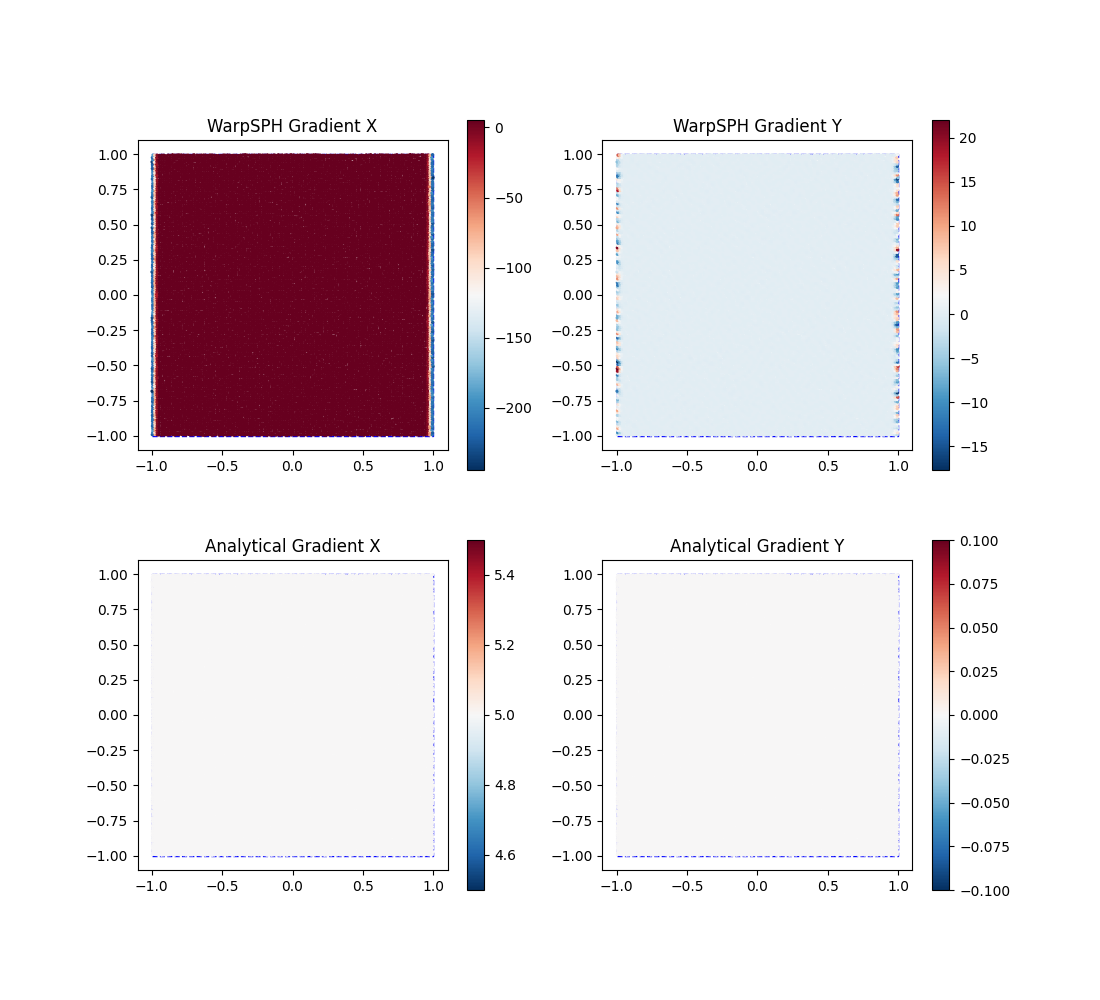

In [4]:
f_linear = particleState.positions[:,0] * 5 + 10
f_grad_x = torch.full_like(f_linear, 5.0)
f_grad_y = torch.zeros_like(f_linear)

linear_gradient_warp = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties=OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = adjacency,
    domain = domain,
)

print("Linear Gradient (WarpSPH): ", linear_gradient_warp)

mean_error_x = torch.mean(torch.abs(linear_gradient_warp[:,0] - f_grad_x))
mean_error_y = torch.mean(torch.abs(linear_gradient_warp[:,1] - f_grad_y))

print("Mean Absolute Error in X Gradient: ", mean_error_x.item())
print("Mean Absolute Error in Y Gradient: ", mean_error_y.item())

fig, axis = plt.subplots(2,2, figsize = (11,10), squeeze=False)
plotToAxis(fig, axis[0,0], particleState, linear_gradient_warp[:,0], "WarpSPH Gradient X", 'RdBu_r', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[0,1], particleState, linear_gradient_warp[:,1], "WarpSPH Gradient Y", 'RdBu_r', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[1,0], particleState, f_grad_x, "Analytical Gradient X", 'RdBu_r', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[1,1], particleState, f_grad_y, "Analytical Gradient Y", 'RdBu_r', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize);

In [5]:
f = torch.randn(numParticles, device=device, dtype=torch.float32)

f_smoothed = f.clone()

for _ in range(4):
    f_smoothed = warpOperation(
        queryParticles = particleState,
        queryValues = f_smoothed,
        operationProperties = OperationProperties(
            kernel = kernel,
            supportMode = supportMode,
            operation = WarpOperation.Interpolate,
        ),
        adjacency = adjacency,
        domain = domain,
    )

gradient_warp = warpOperation(
    queryParticles = particleState,
    queryValues = f_smoothed,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = adjacency,
    domain = domain,
)

gradient_warpNoAdjacency = warpOperation(
    queryParticles = particleState,
    queryValues = f_smoothed,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = None,
    domain = domain,
)


if not warpOnly:
    gradient_diffSPH = SPHOperation(
        simulationState,
        quantity = f_smoothed,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Gradient,
        gradientMode=GradientMode.Difference,
        supportScheme = SupportScheme.Gather,
        correctionTerms= [],
        positiveDivergence=False
    )



Module sphWarpCore.operations.wp_interpolate c4dbeae load on device 'cuda:0' took 1144.01 ms  (compiled)
Module sphWarpCore.operations_grid.wp_gradient_grid 004f1d8 load on device 'cuda:0' took 3180.93 ms  (compiled)


In [6]:
gradient_warp - gradient_warpNoAdjacency

tensor([[ 0.0000e+00,  5.9605e-08],
        [ 0.0000e+00, -5.9605e-08],
        [ 0.0000e+00,  1.1921e-07],
        ...,
        [ 5.9605e-08,  2.3842e-07],
        [ 4.4703e-08,  0.0000e+00],
        [-2.9802e-08, -5.7742e-08]], device='cuda:0')

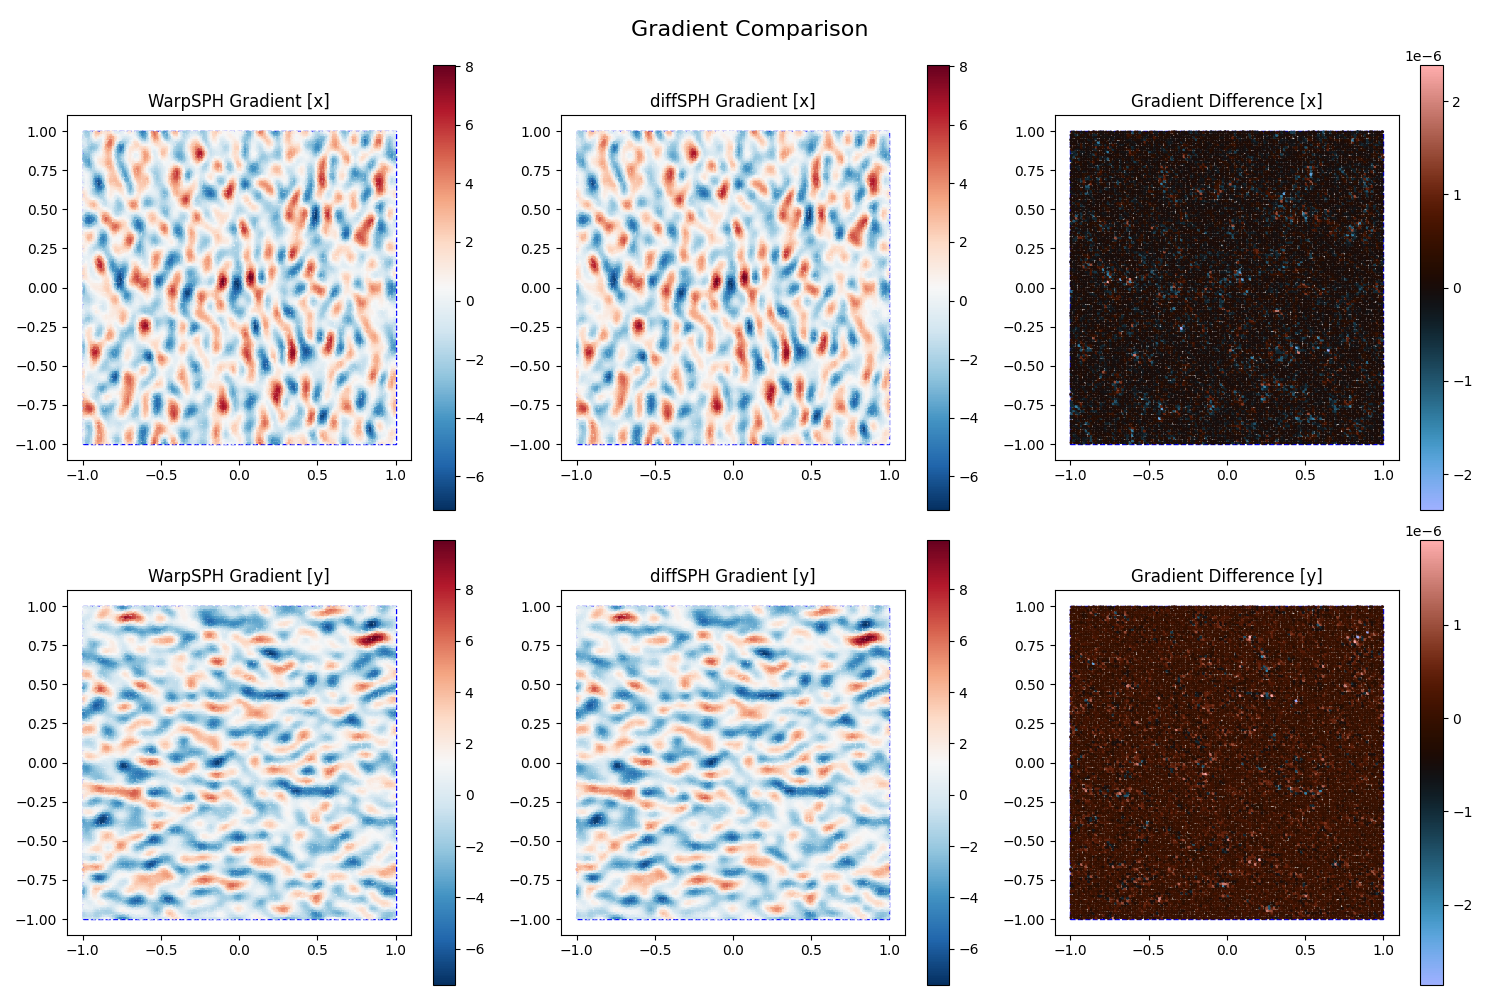

In [7]:
fig, axis = plt.subplots(2,3 if not warpOnly else 1, figsize = (15 if not warpOnly else 11,10), squeeze=False)
markerSize = 8 if warpOnly else 2
gridVisualization = False 
gridResolution = 128


plotToAxis(fig, axis[0,0], particleState, gradient_warp[:,0], "WarpSPH Gradient [x]", 'RdBu_r', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[1,0], particleState, gradient_warp[:,1], "WarpSPH Gradient [y]", 'RdBu_r', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)

if not warpOnly:
    plotToAxis(fig, axis[0,1], particleState, gradient_diffSPH[:,0], "diffSPH Gradient [x]", 'RdBu_r', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
    plotToAxis(fig, axis[1,1], particleState, gradient_diffSPH[:,1], "diffSPH Gradient [y]", 'RdBu_r', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)

    diff_x = gradient_warp[:,0] - gradient_diffSPH[:,0]
    diff_y = gradient_warp[:,1] - gradient_diffSPH[:,1]

    plotToAxis(fig, axis[0,2], particleState, diff_x, "Gradient Difference [x]", 'berlin', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
    plotToAxis(fig, axis[1,2], particleState, diff_y, "Gradient Difference [y]", 'berlin', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)

fig.suptitle("Gradient Comparison" if not warpOnly else "WarpSPH Gradient", fontsize = 16)
fig.tight_layout()


In [8]:
from diffSPH.modules.CRKSPH import computeCRKVolume, computeGeometricMoments, computeCRKTerms, computeCRKDensity, computeVelocityTensor, computeCRKdvdt, computeCRKdudt
from diffSPH.enums import SupportScheme as DiffSPHSupportScheme, KernelType as DiffSPHKernelType, KernelCorrectionScheme

f_linear = particleState.positions[:,0] * 5 + 10
f_grad_x = torch.full_like(f_linear, 5.0)
f_grad_y = torch.zeros_like(f_linear)


In [9]:
gradient_warp = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = adjacency,
    domain = domain
)

gradient_warp_crk = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = adjacency,
    domain = domain,
    crkState = crkState,
    queryVolumes = apparentVolume,
)


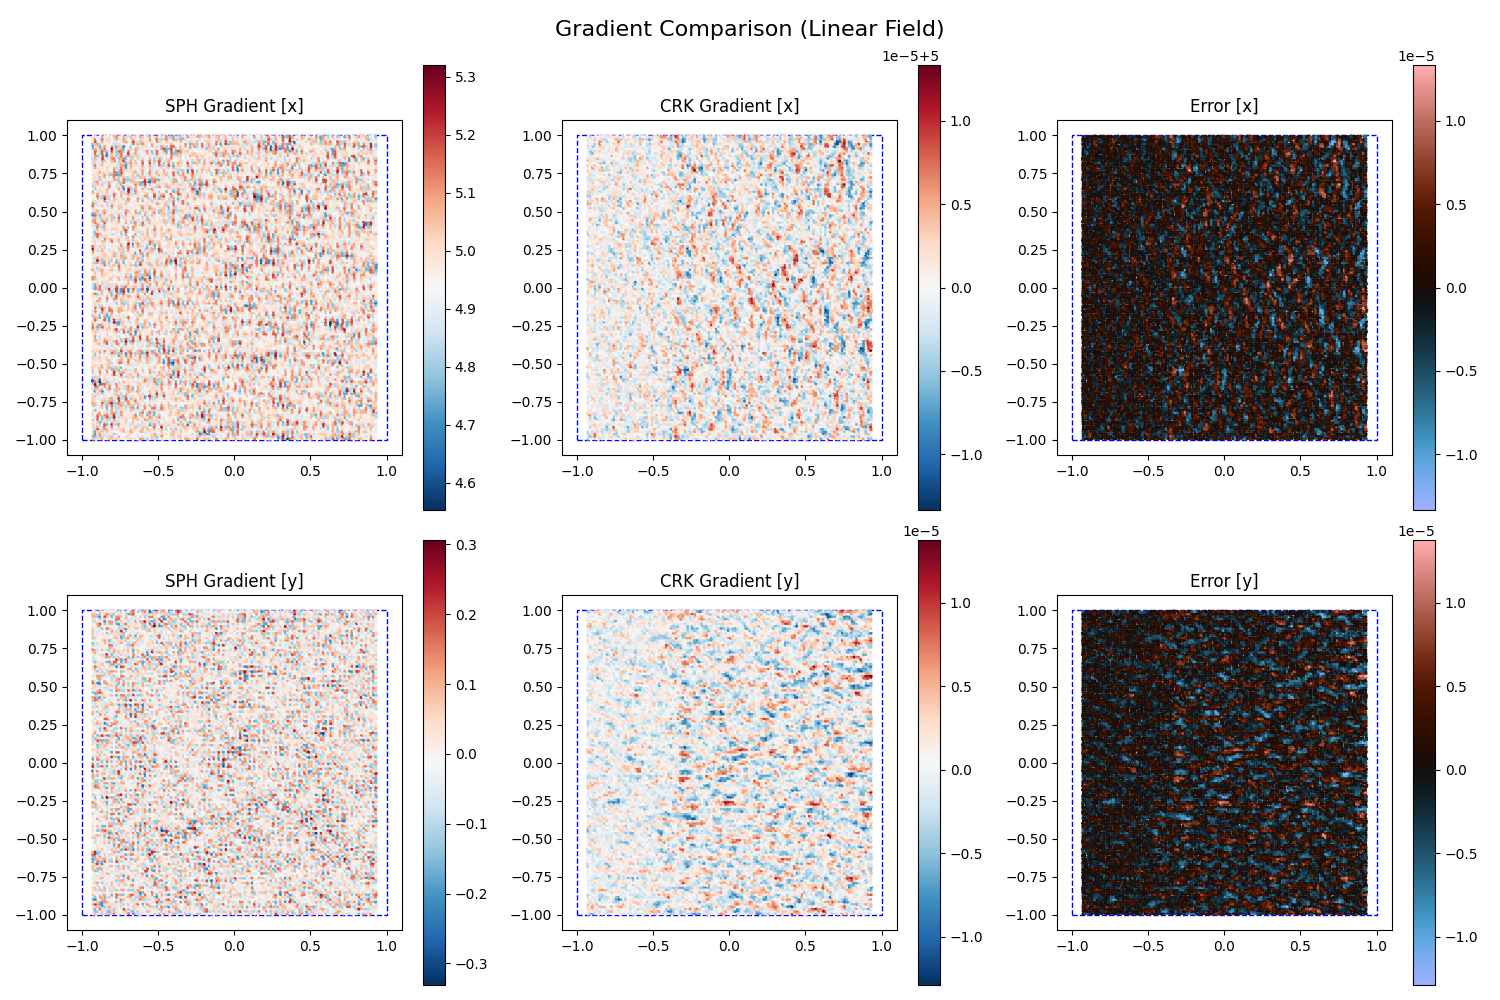

In [10]:
fig, axis = plt.subplots(2, 3, figsize = (15, 10 if not warpOnly else 10), squeeze=False)
mask = torch.logical_and(particleState.positions[:,0] > -1 + dx * 4, particleState.positions[:,0] < 1 - dx * 4)

plotToAxis(fig, axis[0,0], particleState, linear_gradient_warp[:,0], "SPH Gradient [x]", 'RdBu_r', mask = mask, domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[1,0], particleState, linear_gradient_warp[:,1], "SPH Gradient [y]", 'RdBu_r', mask = mask, domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)

plotToAxis(fig, axis[0,1], particleState, gradient_warp_crk[:,0], "CRK Gradient [x]", 'RdBu_r', mask = mask, domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[1,1], particleState, gradient_warp_crk[:,1], "CRK Gradient [y]", 'RdBu_r', mask = mask, domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)

err_x = gradient_warp_crk[:,0] - f_grad_x
err_y = gradient_warp_crk[:,1] - f_grad_y

plotToAxis(fig, axis[0,2], particleState, err_x, "Error [x]", 'berlin', mask = mask, domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[1,2], particleState, err_y, "Error [y]", 'berlin', mask = mask, domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)

fig.suptitle("Gradient Comparison (Linear Field)", fontsize = 16)
fig.tight_layout()

In [11]:
f_interp_warp = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Interpolate,
    ),
    adjacency = adjacency,
    domain = domain,
    crkState = crkState,
    queryVolumes = apparentVolume,
)

f_interp_warp_noCRK = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Interpolate,
    ),
    adjacency = adjacency,
    domain = domain,
    crkState = None,
    queryVolumes = None,
)

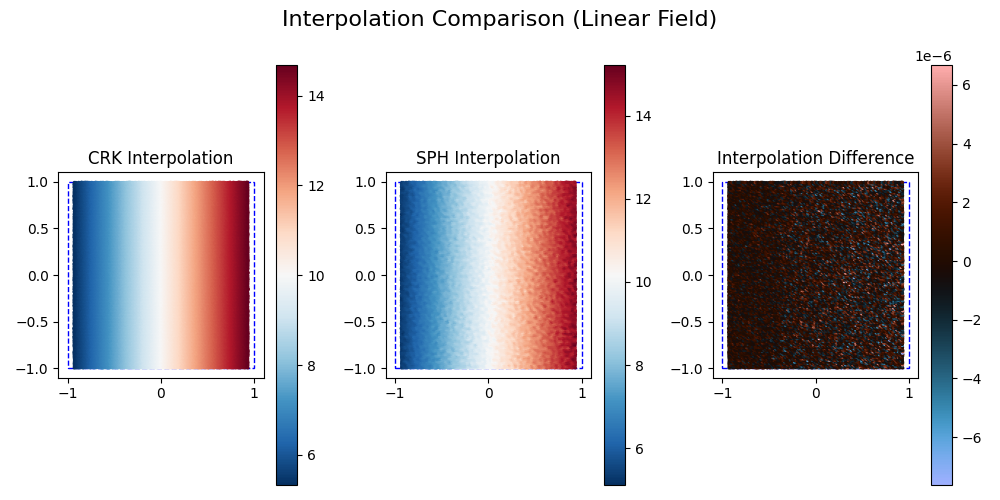

In [12]:
fig, axis = plt.subplots(1, 3, figsize = (10,5), squeeze=False)
mask = torch.logical_and(particleState.positions[:,0] > -1 + dx * 4, particleState.positions[:,0] < 1 - dx * 4)
plotToAxis(fig, axis[0,0], particleState, f_interp_warp, "CRK Interpolation", 'RdBu_r', mask = mask, domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[0,1], particleState, f_interp_warp_noCRK, "SPH Interpolation", 'RdBu_r', mask = mask, domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[0,2], particleState, f_interp_warp - f_linear, "Interpolation Difference", 'berlin', mask = mask, domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
fig.suptitle("Interpolation Comparison (Linear Field)", fontsize = 16)
fig.tight_layout()

In [19]:
device = torch.device('cpu')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
targetNumNeighbors = 8
nx = 128
dim = 1
numParticles = nx**dim

warpOnly = False
periodic = True

kernel = KernelFunctions.Wendland2
supportMode = SupportScheme.Gather

markerSize = 8 if warpOnly else 2
gridVisualization = False 
gridResolution = 128
dx = 2.0 / nx

particleState, domain, adjacency, neighborhood, simulationState, measurements = prepData(nx, targetNumNeighbors, dim, device, periodic, warpOnly)


In [24]:
# particleState.supports = particleState.supports + torch.sin(particleState.positions[:,0] * np.pi) * 0.2 * particleState.supports

particleState.supports = particleState.supports + torch.randn_like(particleState.supports) * 0.25 * particleState.supports

adjacency, adjacency_warp_gpu, adjacency_warp_cpu = timeFunction(radiusSearchCompactHashMap,
        particleState, domain, 
        mode = SupportScheme.SuperSymmetric,
        hashMapLengthMode = HashMapLengthMode.Fixed, fixedHashMapLength = 4096
    )

apparentVolume, crkDensity, crkState = computeCRKFactors(particleState, domain, kernel, adjacency = adjacency)

In [25]:
f_linear = particleState.positions[:,0] * 5 + 10
f_grad_x = torch.full_like(f_linear, 5.0)


In [30]:
f_interp_warp = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = SupportScheme.Scatter,
        operation = WarpOperation.Interpolate,
    ),
    adjacency = adjacency,
    domain = domain,
    crkState = crkState,
    queryVolumes = apparentVolume,
)

f_interp_warp_noCRK = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Interpolate,
    ),
    adjacency = adjacency,
    domain = domain,
    crkState = None,
    queryVolumes = None,
)

gradient_warp = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = adjacency,
    domain = domain
)

gradient_warp_crk = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = SupportScheme.Scatter,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = adjacency,
    domain = domain,
    crkState = crkState,
    queryVolumes = apparentVolume,
)


Text(0.5, 1.0, 'Gradient Error')

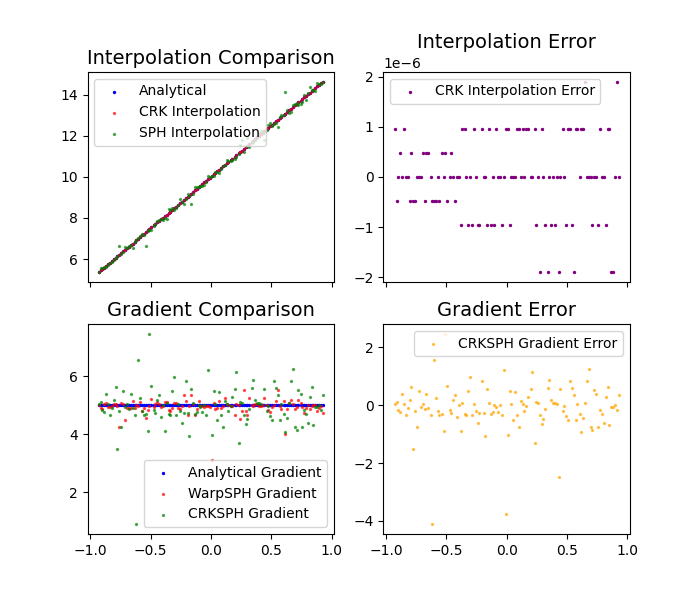

In [29]:
fig, axis = plt.subplots(2, 2, figsize = (7,6), squeeze=False, sharex=True)
mask = torch.logical_and(particleState.positions[:,0] > -1 + dx * 4, particleState.positions[:,0] < 1 - dx * 4)
axis[0,0].scatter(particleState.positions[mask,0].cpu(), f_linear[mask].cpu(), s=markerSize, c='blue', label='Analytical')
axis[0,0].scatter(particleState.positions[mask,0].cpu(), f_interp_warp[mask].cpu(), s=markerSize, c='red', label='CRK Interpolation', alpha=0.6)
axis[0,0].scatter(particleState.positions[mask,0].cpu(), f_interp_warp_noCRK[mask].cpu(), s=markerSize, c='green', label='SPH Interpolation', alpha=0.6)
axis[0,0].legend()
axis[0,0].set_title("Interpolation Comparison", fontsize=14)

axis[1,0].scatter(particleState.positions[mask,0].cpu(), f_grad_x[mask].cpu(), s=markerSize, c='blue', label='Analytical Gradient')
axis[1,0].scatter(particleState.positions[mask,0].cpu(), gradient_warp[mask,0].cpu(), s=markerSize, c='red', label='WarpSPH Gradient', alpha=0.6)
axis[1,0].scatter(particleState.positions[mask,0].cpu(), gradient_warp_crk[mask,0].cpu(), s=markerSize, c='green', label='CRKSPH Gradient', alpha=0.6)
axis[1,0].legend()
axis[1,0].set_title("Gradient Comparison", fontsize=14)

axis[0,1].scatter(particleState.positions[mask,0].cpu(), (f_interp_warp - f_linear)[mask].cpu(), s=markerSize, c='purple', label='CRK Interpolation Error')
# axis[0,1].scatter(particleState.positions[mask,0].cpu(), (f_interp_warp_noCRK - f_linear)[mask].cpu(), s=markerSize, c='orange', label='SPH Interpolation Error', alpha=0.6)
axis[0,1].legend()
axis[0,1].set_title("Interpolation Error", fontsize=14)

# axis[1,1].scatter(particleState.positions[mask,0].cpu(), (gradient_warp[:,0] - f_grad_x)[mask].cpu(), s=markerSize, c='purple', label='WarpSPH Gradient Error')
axis[1,1].scatter(particleState.positions[mask,0].cpu(), (gradient_warp_crk[:,0] - f_grad_x)[mask].cpu(), s=markerSize, c='orange', label='CRKSPH Gradient Error', alpha=0.6)
axis[1,1].legend()
axis[1,1].set_title("Gradient Error", fontsize=14)